<a href="https://colab.research.google.com/github/SamuelBG-SVG/Proyecto---Grietas/blob/main/04_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Modelo de línea base cargado correctamente desde Drive.


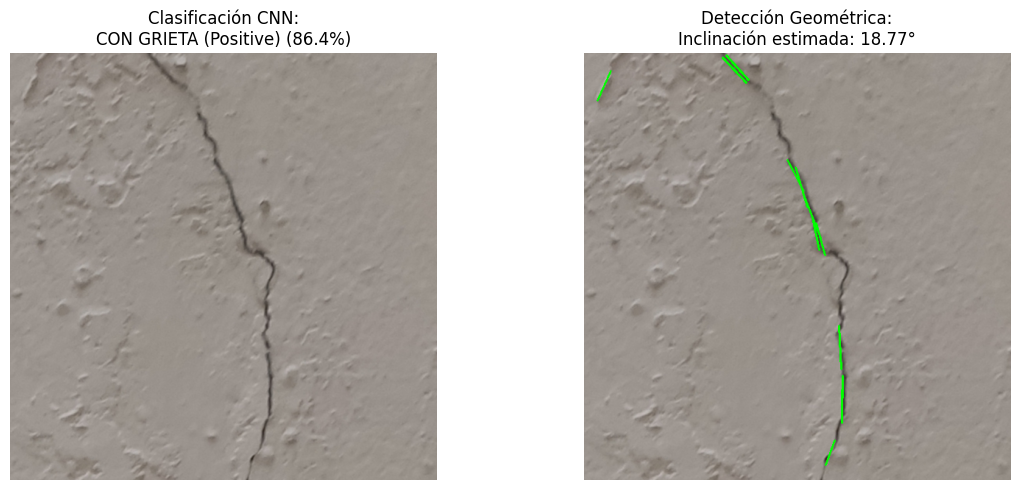

         REPORTE FINAL - ENTREGA 1
• Valor Salida Sigmoid : 0.1365
• Diagnóstico Grieta   : CON GRIETA (Positive)
• Nivel de Confianza   : 86.35%
• Inclinación Estimada : 18.77° respecto a la vertical



In [ ]:
# ==============================================================================
# 04_demo_entrega1.ipynb
# Proyecto: Detección de Grietas e Inclinación Estructural (Entrega 1)
# ==============================================================================

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from google.colab import drive

# 1. Montar Google Drive
drive.mount('/content/drive')

# 2. Cargar el modelo entrenado desde la carpeta Models/
ruta_modelo = '/content/drive/MyDrive/Proyecto_Grietas/Models/modelo_linea_base.keras'

if os.path.exists(ruta_modelo):
    model = tf.keras.models.load_model(ruta_modelo)
    print("✅ Modelo de línea base cargado correctamente desde Drive.")
else:
    print("❌ Error: No se encontró el archivo del modelo en:", ruta_modelo)

# 3. Función unificada para la evaluación completa
def evaluar_foto_procedimiento_completo(ruta_imagen):
    # A. Cargar imagen con OpenCV y convertir a RGB
    img_bgr = cv2.imread(ruta_imagen)
    if img_bgr is None:
        print(f"❌ No se pudo cargar la imagen: {ruta_imagen}")
        return

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # B. Preprocesamiento idéntico al entrenamiento
    img_resized = cv2.resize(img_rgb, (128, 128))
    img_arr = img_resized.astype("float32") / 255.0
    img_arr = np.expand_dims(img_arr, axis=0)

    # Predicción del modelo
    pred = model.predict(img_arr, verbose=0)[0][0]


    if pred < 0.5:
        clase_texto = "CON GRIETA (Positive)"
        confianza = (1.0 - pred) * 100
    else:
        clase_texto = "SIN GRIETA (Negative)"
        confianza = pred * 100

    # C. Estimación de Inclinación con OpenCV
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blur, 50, 150, apertureSize=3)
    lines = cv2.HoughLinesP(edges, 1, np.pi/180, threshold=30, minLineLength=30, maxLineGap=10)

    angulos = []
    img_lineas = img_rgb.copy()

    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line[0]
            cv2.line(img_lineas, (x1, y1), (x2, y2), (0, 255, 0), 2)
            dx = abs(x2 - x1)
            dy = abs(y2 - y1)
            if dy != 0:
                angulo_rad = np.arctan2(dx, dy)
                angulos.append(np.degrees(angulo_rad))

        angulo_promedio = np.mean(angulos) if len(angulos) > 0 else 0.0
    else:
        angulo_promedio = 0.0

    # D. Visualización
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].imshow(img_rgb)
    axes[0].set_title(f"Clasificación CNN:\n{clase_texto} ({confianza:.1f}%)")
    axes[0].axis('off')

    axes[1].imshow(img_lineas)
    axes[1].set_title(f"Detección Geométrica:\nInclinación estimada: {angulo_promedio:.2f}°")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

    # E. Reporte impreso
    print("=" * 50)
    print("         REPORTE FINAL - ENTREGA 1")
    print("=" * 50)
    print(f"• Valor Salida Sigmoid : {pred:.4f}")
    print(f"• Diagnóstico Grieta   : {clase_texto}")
    print(f"• Nivel de Confianza   : {confianza:.2f}%")
    print(f"• Inclinación Estimada : {angulo_promedio:.2f}° respecto a la vertical")
    print("=" * 50 + "\n")

# ==============================================================================
# PRUEBA DE LA DEMO COMPLETA
# ==============================================================================
# Cambia esta ruta por cualquier imagen de prueba o foto de tu celular
ruta_prueba = '/content/drive/MyDrive/Proyecto_Grietas/data/Dataset_propio/prueba_am.jpeg'
evaluar_foto_procedimiento_completo(ruta_prueba)